In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from time import perf_counter
import os
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from tensorflow.keras.utils import plot_model

In [ ]:
!unzip /content/abc.zip

Streaming output truncated to the last 5000 lines.
  inflating: SeverityScore/Severity Score Dataset with Labels/1/387.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/388.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/389.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/39.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/390.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/391.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/392.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/393.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/394.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/395.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/396.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/1/397.jpg  
  inflating: SeverityScore/Severity Score Dataset with Labels/

In [ ]:
## Defining batch specfications
batch_size = 100
img_height = 250
img_width = 250

In [ ]:
import os
import shutil

# Source folders
accident_src = "/content/Accident/Accident"
nonaccident_src = "/content/NonAccident/NonAccident"

# Destination folders
accident_dst = "/content/Accident"
nonaccident_dst = "/content/NonAccident"

# Move Accident images
for file in os.listdir(accident_src):
    src = os.path.join(accident_src, file)
    dst = os.path.join(accident_dst, file)

    if os.path.isfile(src):
        shutil.move(src, dst)

# Move NonAccident images
for file in os.listdir(nonaccident_src):
    src = os.path.join(nonaccident_src, file)
    dst = os.path.join(nonaccident_dst, file)

    if os.path.isfile(src):
        shutil.move(src, dst)

print("Images moved successfully.")

Images moved successfully.


In [ ]:
import shutil
import os

shutil.rmtree("/content/Accident/Accident")
shutil.rmtree("/content/NonAccident/NonAccident")

print("Nested folders removed.")

Nested folders removed.


In [ ]:
import os
import shutil
import random

random.seed(42)

# Original folders
source_dirs = {
    "Accident": "/content/Accident",
    "NonAccident": "/content/NonAccident"
}

# Final dataset directory
dataset_dir = "/content/dataset"

# Create folders
for split in ["train", "validation", "test"]:
    for class_name in ["Accident", "NonAccident"]:
        os.makedirs(
            os.path.join(dataset_dir, split, class_name),
            exist_ok=True
        )

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

for class_name, source_dir in source_dirs.items():

    # Get image files
    images = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith((
            ".jpg", ".jpeg", ".png", ".bmp", ".webp"
        ))
    ]

    # Shuffle
    random.shuffle(images)

    total = len(images)

    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy images
    for image in train_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(dataset_dir, "train", class_name, image)
        )

    for image in val_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(dataset_dir, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(dataset_dir, "test", class_name, image)
        )

    print(f"\n{class_name}")
    print(f"Total:      {total}")
    print(f"Train:      {len(train_images)}")
    print(f"Validation: {len(val_images)}")
    print(f"Test:       {len(test_images)}")


Accident
Total:      6191
Train:      4333
Validation: 928
Test:       930

NonAccident
Total:      15420
Train:      10794
Validation: 2313
Test:       2313


In [ ]:
import os
import shutil
import random

# ============================================================
# SETTINGS
# ============================================================

random.seed(42)

SOURCE_ACCIDENT = "/content/Accident"
SOURCE_NONACCIDENT = "/content/NonAccident"

OUTPUT_DIR = "/content/cnn_dataset"

TARGET_PER_CLASS = 3000

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ============================================================
# GET IMAGES
# ============================================================

accident_images = [
    f for f in os.listdir(SOURCE_ACCIDENT)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

nonaccident_images = [
    f for f in os.listdir(SOURCE_NONACCIDENT)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

print("Available images:")
print("Accident:", len(accident_images))
print("NonAccident:", len(nonaccident_images))

# ============================================================
# SELECT EXACTLY 3000 FROM EACH CLASS
# ============================================================

random.shuffle(accident_images)
random.shuffle(nonaccident_images)

accident_images = accident_images[:TARGET_PER_CLASS]
nonaccident_images = nonaccident_images[:TARGET_PER_CLASS]

print("\nSelected images:")
print("Accident:", len(accident_images))
print("NonAccident:", len(nonaccident_images))

# ============================================================
# CREATE FOLDERS
# ============================================================

for split in ["train", "validation", "test"]:
    for class_name in ["Accident", "NonAccident"]:
        os.makedirs(
            os.path.join(OUTPUT_DIR, split, class_name),
            exist_ok=True
        )

# ============================================================
# SPLIT FUNCTION
# ============================================================

def split_dataset(images):

    total = len(images)

    train_count = int(total * 0.70)
    validation_count = int(total * 0.15)

    train = images[:train_count]
    validation = images[train_count:train_count + validation_count]
    test = images[train_count + validation_count:]

    return train, validation, test


# ============================================================
# SPLIT DATA
# ============================================================

accident_train, accident_val, accident_test = split_dataset(
    accident_images
)

nonaccident_train, nonaccident_val, nonaccident_test = split_dataset(
    nonaccident_images
)

# ============================================================
# COPY FUNCTION
# ============================================================

def copy_images(images, source_dir, destination_dir):

    for image in images:

        source = os.path.join(source_dir, image)
        destination = os.path.join(destination_dir, image)

        shutil.copy2(source, destination)


# ============================================================
# COPY ACCIDENT
# ============================================================

copy_images(
    accident_train,
    SOURCE_ACCIDENT,
    os.path.join(OUTPUT_DIR, "train", "Accident")
)

copy_images(
    accident_val,
    SOURCE_ACCIDENT,
    os.path.join(OUTPUT_DIR, "validation", "Accident")
)

copy_images(
    accident_test,
    SOURCE_ACCIDENT,
    os.path.join(OUTPUT_DIR, "test", "Accident")
)

# ============================================================
# COPY NON-ACCIDENT
# ============================================================

copy_images(
    nonaccident_train,
    SOURCE_NONACCIDENT,
    os.path.join(OUTPUT_DIR, "train", "NonAccident")
)

copy_images(
    nonaccident_val,
    SOURCE_NONACCIDENT,
    os.path.join(OUTPUT_DIR, "validation", "NonAccident")
)

copy_images(
    nonaccident_test,
    SOURCE_NONACCIDENT,
    os.path.join(OUTPUT_DIR, "test", "NonAccident")
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 55)
print("CNN DATASET CREATED")
print("=" * 55)

print("\nTRAIN")
print("Accident:    ", len(accident_train))
print("NonAccident: ", len(nonaccident_train))

print("\nVALIDATION")
print("Accident:    ", len(accident_val))
print("NonAccident: ", len(nonaccident_val))

print("\nTEST")
print("Accident:    ", len(accident_test))
print("NonAccident: ", len(nonaccident_test))

print("\nTOTAL")
print("Accident:    ", len(accident_images))
print("NonAccident: ", len(nonaccident_images))

print("\nDataset path:")
print(OUTPUT_DIR)

Available images:
Accident: 6191
NonAccident: 15420

Selected images:
Accident: 3000
NonAccident: 3000

CNN DATASET CREATED

TRAIN
Accident:     2100
NonAccident:  2100

VALIDATION
Accident:     450
NonAccident:  450

TEST
Accident:     450
NonAccident:  450

TOTAL
Accident:     3000
NonAccident:  3000

Dataset path:
/content/cnn_dataset


In [ ]:
## loading training set
training_data = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/cnn_dataset/train',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 4200 files belonging to 2 classes.


In [ ]:
## loading validation dataset
validation_data =  tf.keras.preprocessing.image_dataset_from_directory(
    '/content/cnn_dataset/validation',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 900 files belonging to 2 classes.


In [ ]:
## loading testing dataset
testing_data = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/cnn_dataset/test',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 900 files belonging to 2 classes.


In [ ]:
testing_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
class_names = training_data.class_names
class_names

['Accident', 'NonAccident']

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
img_height = 224
img_width = 224
batch_size = 32

train_path = "/content/cnn_dataset/train"
val_path = "/content/cnn_dataset/validation"
test_path = "/content/cnn_dataset/test"

In [ ]:
training_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb",
    shuffle=True
)

validation_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb",
    shuffle=False
)

testing_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb",
    shuffle=False
)

Found 4200 files belonging to 2 classes.
Found 900 files belonging to 2 classes.
Found 900 files belonging to 2 classes.


In [ ]:
print("Classes:", training_data.class_names)

Classes: ['Accident', 'NonAccident']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

training_data = training_data.prefetch(AUTOTUNE)
validation_data = validation_data.prefetch(AUTOTUNE)
testing_data = testing_data.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [ ]:
model = models.Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixels from [0,255] -> [0,1]
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary classification
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "/content/best_accident_cnn.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
restore_best_weights=True

In [ ]:
history = model.fit(
    training_data,
    validation_data=validation_data,
    epochs=30,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ]
)

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5741 - loss: 0.7447
Epoch 1: val_accuracy improved from None to 0.49444, saving model to /content/best_accident_cnn.keras

Epoch 1: finished saving model to /content/best_accident_cnn.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 28s 135ms/step - accuracy: 0.6019 - loss: 0.6938 - val_accuracy: 0.4944 - val_loss: 0.8243 - learning_rate: 0.0010
Epoch 2/30
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6388 - loss: 0.6306
Epoch 2: val_accuracy improved from 0.49444 to 0.50333, saving model to /content/best_accident_cnn.keras

Epoch 2: finished saving model to /content/best_accident_cnn.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.6526 - loss: 0.6251 - val_accuracy: 0.5033 - val_loss: 1.0350 - learning_rate: 0.0010
Epoch 3/30
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6609 - loss: 0.6175
Epoch 3: val_accuracy improved from 0.50333 to 0.57889, saving model to /content/best_accident_cnn.keras


In [ ]:
best_model = tf.keras.models.load_model(
    "/content/best_accident_cnn.keras"
)

In [ ]:
test_loss, test_accuracy = best_model.evaluate(
    testing_data,
    verbose=1
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7744 - loss: 0.4905

FINAL TEST RESULTS
Test Loss:     0.4905
Test Accuracy: 77.44%


In [ ]:
import tensorflow as tf
import numpy as np

TEST_DIR = "/content/cnn_dataset/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nClass names:", test_raw.class_names)
print("Class indices:", {
    name: i for i, name in enumerate(test_raw.class_names)
})

print("\nRunning model predictions...")

all_labels = []
all_predictions = []

for images, labels in test_raw:
    predictions = model.predict(images, verbose=0)

    all_labels.extend(labels.numpy())
    all_predictions.extend(predictions.flatten())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("\nTotal test images:", len(all_labels))

print("\nFirst 20 labels:")
print(all_labels[:20])

print("\nFirst 20 raw predictions:")
print(np.round(all_predictions[:20], 4))

Found 900 files belonging to 2 classes.

Class names: ['Accident', 'NonAccident']
Class indices: {'Accident': 0, 'NonAccident': 1}

Running model predictions...

Total test images: 900

First 20 labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 raw predictions:
[0.0401 0.0841 0.4711 0.2508 0.4603 0.3979 0.2598 0.5262 0.3812 0.4363
 0.4788 0.0575 0.4828 0.448  0.1445 0.4401 0.4328 0.29   0.4214 0.2063]


In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Convert sigmoid output to class prediction
# 0 = Accident
# 1 = NonAccident

predicted_labels = (all_predictions >= 0.5).astype(int)

accuracy = accuracy_score(all_labels, predicted_labels)
precision = precision_score(all_labels, predicted_labels)
recall = recall_score(all_labels, predicted_labels)
f1 = f1_score(all_labels, predicted_labels)

cm = confusion_matrix(all_labels, predicted_labels)

print("=" * 60)
print("CNN MODEL TEST RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        predicted_labels,
        target_names=["Accident", "NonAccident"]
    )
)

print("=" * 60)

CNN MODEL TEST RESULTS
Accuracy  : 76.56%
Precision : 75.92%
Recall    : 77.78%
F1 Score  : 76.84%

Confusion Matrix:
[[339 111]
 [100 350]]

Classification Report:
              precision    recall  f1-score   support

    Accident       0.77      0.75      0.76       450
 NonAccident       0.76      0.78      0.77       450

    accuracy                           0.77       900
   macro avg       0.77      0.77      0.77       900
weighted avg       0.77      0.77      0.77       900



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Convert model output to Accident probability
accident_probs = 1 - all_predictions

print("=" * 70)
print("THRESHOLD ANALYSIS")
print("=" * 70)

for threshold in [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]:

    # Accident = 0
    # NonAccident = 1
    predicted = np.where(
        accident_probs >= threshold,
        0,
        1
    )

    cm = confusion_matrix(
        all_labels,
        predicted
    )

    precision = precision_score(
        all_labels,
        predicted,
        pos_label=0
    )

    recall = recall_score(
        all_labels,
        predicted,
        pos_label=0
    )

    f1 = f1_score(
        all_labels,
        predicted,
        pos_label=0
    )

    accuracy = np.mean(
        predicted == all_labels
    )

    print(
        f"\nThreshold: {threshold * 100:.0f}%"
    )
    print(
        f"Accuracy : {accuracy * 100:.2f}%"
    )
    print(
        f"Precision: {precision * 100:.2f}%"
    )
    print(
        f"Recall   : {recall * 100:.2f}%"
    )
    print(
        f"F1 Score : {f1 * 100:.2f}%"
    )
    print(
        f"Missed Accidents: {cm[0][1]}"
    )
    print(
        f"False Alarms:     {cm[1][0]}"
    )

THRESHOLD ANALYSIS

Threshold: 50%
Accuracy : 76.56%
Precision: 77.22%
Recall   : 75.33%
F1 Score : 76.27%
Missed Accidents: 111
False Alarms:     100

Threshold: 60%
Accuracy : 71.89%
Precision: 83.85%
Recall   : 54.22%
F1 Score : 65.86%
Missed Accidents: 206
False Alarms:     47

Threshold: 70%
Accuracy : 65.89%
Precision: 90.86%
Recall   : 35.33%
F1 Score : 50.88%
Missed Accidents: 291
False Alarms:     16

Threshold: 80%
Accuracy : 59.44%
Precision: 94.74%
Recall   : 20.00%
F1 Score : 33.03%
Missed Accidents: 360
False Alarms:     5

Threshold: 85%
Accuracy : 56.11%
Precision: 96.61%
Recall   : 12.67%
F1 Score : 22.40%
Missed Accidents: 393
False Alarms:     2

Threshold: 90%
Accuracy : 52.78%
Precision: 96.30%
Recall   : 5.78%
F1 Score : 10.90%
Missed Accidents: 424
False Alarms:     1

Threshold: 95%
Accuracy : 50.33%
Precision: 100.00%
Recall   : 0.67%
F1 Score : 1.32%
Missed Accidents: 447
False Alarms:     0


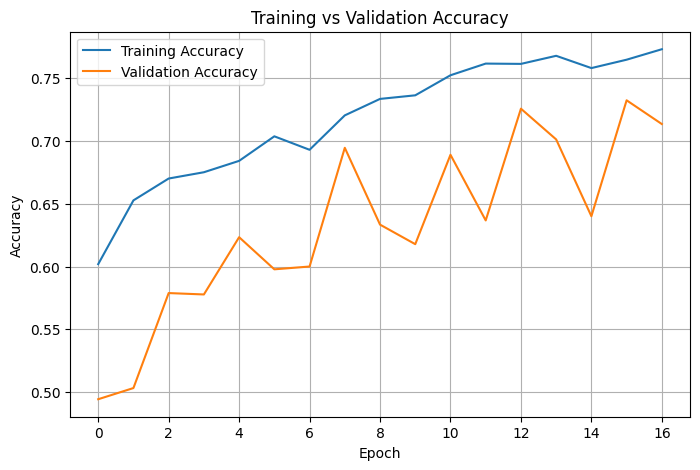

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

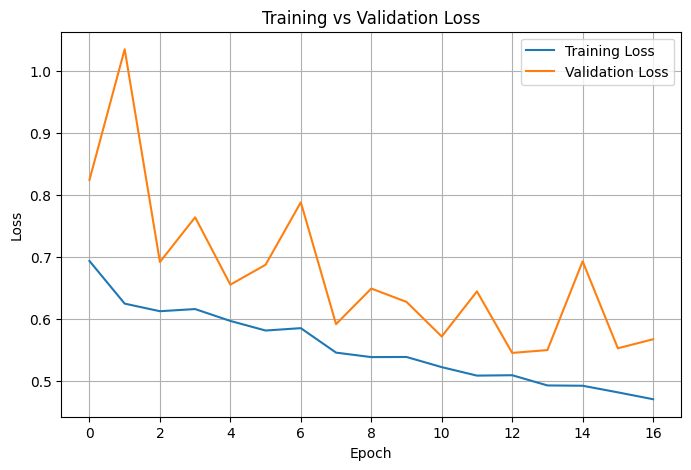

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# 3 test image paths
image_paths = [
    "/content/cnn_dataset/test/Accident/1046.jpg",
    "/content/cnn_dataset/test/Accident/1081.jpg",
    "/content/cnn_dataset/test/Accident/1213.jpg"
]

for image_path in image_paths:

    # Load image
    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    # Convert image to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = tf.expand_dims(
        img_array,
        0
    )

    # Prediction
    prediction = best_model.predict(
        img_array,
        verbose=0
    )[0][0]

    # Display result
    if prediction >= 0.5:
        result = "NonAccident"
    else:
        result = "Accident"

    print("=" * 50)
    print("Image:", image_path)
    print("Prediction:", result)
    print("Raw prediction:", prediction)

Image: /content/cnn_dataset/test/Accident/1046.jpg
Prediction: Accident
Raw prediction: 0.010285063
Image: /content/cnn_dataset/test/Accident/1081.jpg
Prediction: Accident
Raw prediction: 0.039106593
Image: /content/cnn_dataset/test/Accident/1213.jpg
Prediction: Accident
Raw prediction: 0.13691667


In [ ]:
import os
import random
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

test_dir = "/content/cnn_dataset/test"

# Get images from both classes
accident_dir = os.path.join(test_dir, "Accident")
nonaccident_dir = os.path.join(test_dir, "NonAccident")

accident_images = [
    os.path.join(accident_dir, f)
    for f in os.listdir(accident_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

nonaccident_images = [
    os.path.join(nonaccident_dir, f)
    for f in os.listdir(nonaccident_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select 2 Accident + 1 NonAccident
selected_images = (
    random.sample(accident_images, 2) +
    random.sample(nonaccident_images, 1)
)

# Test images
for image_path in selected_images:

    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    img_array = img_to_array(img)

    img_array = tf.expand_dims(
        img_array,
        0
    )

    prediction = best_model.predict(
        img_array,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        result = "NonAccident"
    else:
        result = "Accident"

    print("=" * 60)
    print("Actual class :", os.path.basename(os.path.dirname(image_path)))
    print("Image        :", os.path.basename(image_path))
    print("Prediction   :", result)
    print("Raw score    :", round(float(prediction), 4))

Actual class : Accident
Image        : 3138.jpg
Prediction   : Accident
Raw score    : 0.4306
Actual class : Accident
Image        : 4653.jpg
Prediction   : Accident
Raw score    : 0.2497
Actual class : NonAccident
Image        : 10843.jpg
Prediction   : NonAccident
Raw score    : 0.6667


In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# Test images
test_images = [
    # NonAccident
    ("/content/cnn_dataset/test/NonAccident/10765.jpg", "NonAccident"),
    ("/content/cnn_dataset/test/NonAccident/10730.jpg", "NonAccident"),
    ("/content/cnn_dataset/test/NonAccident/11034.jpg", "NonAccident"),
    ("/content/cnn_dataset/test/NonAccident/1125.jpg", "NonAccident"),

    # Accident
    ("/content/cnn_dataset/test/Accident/1273.jpg", "Accident"),
    ("/content/cnn_dataset/test/Accident/1477.jpg", "Accident"),
    ("/content/cnn_dataset/test/Accident/1607.jpg", "Accident"),
    ("/content/cnn_dataset/test/Accident/2101.jpg", "Accident")
]

correct = 0

for image_path, actual_class in test_images:

    # Load image
    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    # Convert image to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = tf.expand_dims(img_array, 0)

    # Predict
    prediction = best_model.predict(
        img_array,
        verbose=0
    )[0][0]

    # Convert prediction to class
    if prediction >= 0.5:
        predicted_class = "NonAccident"
    else:
        predicted_class = "Accident"

    # Check correctness
    if predicted_class == actual_class:
        correct += 1
        status = "✓ Correct"
    else:
        status = "✗ Wrong"

    print("=" * 60)
    print("Image          :", image_path.split("/")[-1])
    print("Actual Class   :", actual_class)
    print("Predicted Class:", predicted_class)
    print("Raw Prediction :", round(float(prediction), 4))
    print("Status         :", status)

# Overall accuracy
accuracy = (correct / len(test_images)) * 100

print("\n" + "=" * 60)
print(f"Correct Predictions: {correct}/{len(test_images)}")
print(f"Test Accuracy      : {accuracy:.2f}%")
print("=" * 60)

Image          : 10765.jpg
Actual Class   : NonAccident
Predicted Class: NonAccident
Raw Prediction : 0.8288
Status         : ✓ Correct
Image          : 10730.jpg
Actual Class   : NonAccident
Predicted Class: NonAccident
Raw Prediction : 0.7905
Status         : ✓ Correct
Image          : 11034.jpg
Actual Class   : NonAccident
Predicted Class: NonAccident
Raw Prediction : 0.7832
Status         : ✓ Correct
Image          : 1125.jpg
Actual Class   : NonAccident
Predicted Class: NonAccident
Raw Prediction : 0.6061
Status         : ✓ Correct
Image          : 1273.jpg
Actual Class   : Accident
Predicted Class: NonAccident
Raw Prediction : 0.5738
Status         : ✗ Wrong
Image          : 1477.jpg
Actual Class   : Accident
Predicted Class: NonAccident
Raw Prediction : 0.5901
Status         : ✗ Wrong
Image          : 1607.jpg
Actual Class   : Accident
Predicted Class: Accident
Raw Prediction : 0.4992
Status         : ✓ Correct
Image          : 2101.jpg
Actual Class   : Accident
Predicted Class:

In [ ]:
# ============================================================
# SAVE CNN MODEL ARCHITECTURE + WEIGHTS
# ============================================================

import tensorflow as tf
import os

# Load your best saved model
best_model = tf.keras.models.load_model(
    "/content/best_accident_cnn.keras"
)

# ------------------------------------------------------------
# 1. Save model architecture
# ------------------------------------------------------------

model_json = best_model.to_json()

with open("/content/model.json", "w") as json_file:
    json_file.write(model_json)

# ------------------------------------------------------------
# 2. Save model weights
# ------------------------------------------------------------

best_model.save_weights(
    "/content/model_weights.weights.h5"
)

# ------------------------------------------------------------
# 3. Verify files
# ------------------------------------------------------------

print("=" * 55)
print("MODEL FILES SAVED SUCCESSFULLY")
print("=" * 55)

print("\nArchitecture:")
print("/content/model.json")

print("\nWeights:")
print("/content/model_weights.weights.h5")

print("\nModel input shape:", best_model.input_shape)
print("Model output shape:", best_model.output_shape)

print("\nFiles exist:")
print("model.json:",
      os.path.exists("/content/model.json"))

print("model_weights.weights.h5:",
      os.path.exists("/content/model_weights.weights.h5"))

# ------------------------------------------------------------
# 4. Download both files
# ------------------------------------------------------------

from google.colab import files

files.download("/content/model.json")
files.download("/content/model_weights.weights.h5")

MODEL FILES SAVED SUCCESSFULLY

Architecture:
/content/model.json

Weights:
/content/model_weights.weights.h5

Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1)

Files exist:
model.json: True
model_weights.weights.h5: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **============================================================**

In [ ]:
import os

DATASET_PATH = "/content/cnn_dataset"

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["Accident", "NonAccident"]:
        path = os.path.join(DATASET_PATH, split, cls)
        print(f"{cls}: {len(os.listdir(path))} images")


TRAIN
Accident: 2100 images
NonAccident: 2100 images

VALIDATION
Accident: 450 images
NonAccident: 450 images

TEST
Accident: 450 images
NonAccident: 450 images


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 15
EPOCHS_FINE = 20

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/cnn_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    "/content/cnn_dataset/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/cnn_dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_data.class_names)

Found 4200 files belonging to 2 classes.
Found 900 files belonging to 2 classes.
Found 900 files belonging to 2 classes.
Classes: ['Accident', 'NonAccident']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(AUTOTUNE)
validation_data = validation_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="EfficientNetB0_Accident_Detection"
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Accident_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
checkpoint_path = "/content/efficientnetb0_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
history_head = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)

Epoch 1/15
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6456 - loss: 0.7792 - precision: 0.6406 - recall: 0.6553
Epoch 1: val_loss improved from None to 0.52773, saving model to /content/efficientnetb0_best.keras

Epoch 1: finished saving model to /content/efficientnetb0_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 166ms/step - accuracy: 0.6926 - loss: 0.6827 - precision: 0.6898 - recall: 0.7000 - val_accuracy: 0.7544 - val_loss: 0.5277 - val_precision: 0.7657 - val_recall: 0.7333 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7421 - loss: 0.5756 - precision: 0.7417 - recall: 0.7310
Epoch 2: val_loss improved from 0.52773 to 0.44355, saving model to /content/efficientnetb0_best.keras

Epoch 2: finished saving model to /content/efficientnetb0_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.7583 - loss: 0.5297 - precision: 0.7602 - recall: 0.7548 - val_accuracy: 0.7778 - val_loss: 0.4435 - val_precision: 0.8005 - 

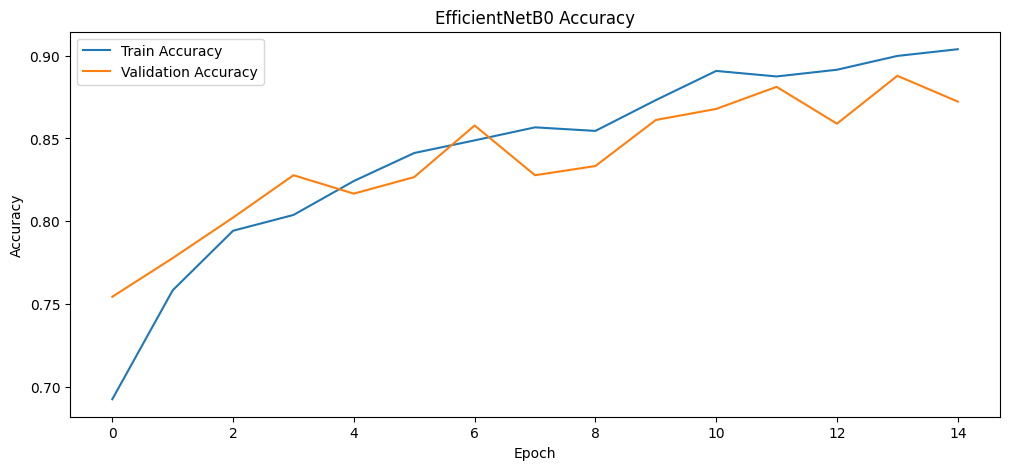

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_head.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_head.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.legend()
plt.show()

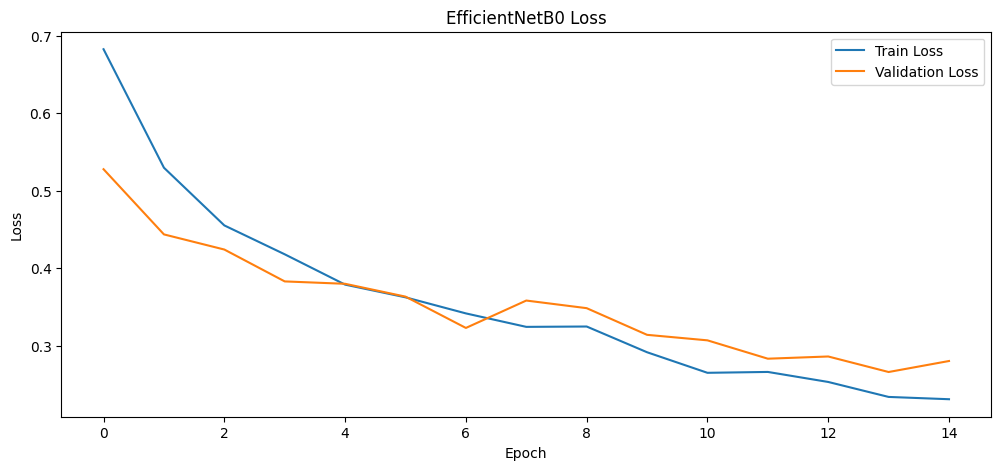

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_head.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_head.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss")
plt.legend()
plt.show()

In [ ]:
base_model.trainable = True

# Freeze the early layers
fine_tune_from = 180

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Trainable layers: 58


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)

Epoch 1/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7882 - loss: 0.4721 - precision: 0.7853 - recall: 0.7888
Epoch 1: val_loss did not improve from 0.26583
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.7976 - loss: 0.4424 - precision: 0.7959 - recall: 0.8005 - val_accuracy: 0.8811 - val_loss: 0.2957 - val_precision: 0.8657 - val_recall: 0.9022 - learning_rate: 1.0000e-05
Epoch 2/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8106 - loss: 0.4039 - precision: 0.8025 - recall: 0.8147
Epoch 2: val_loss did not improve from 0.26583

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
132/132 ━━━━━━━━━━━━━━━━━━━━ 19s 143ms/step - accuracy: 0.8169 - loss: 0.3949 - precision: 0.8150 - recall: 0.8200 - val_accuracy: 0.8678 - val_loss: 0.3026 - val_precision: 0.8702 - val_recall: 0.8644 - learning_rate: 1.0000e-05
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8395 - loss: 0.3601 - precision: 0.8268 - recall: 

In [ ]:
test_results = model.evaluate(
    test_data,
    verbose=1
)

print("\nTEST RESULTS")

for name, value in zip(
    model.metrics_names,
    test_results
):
    print(
        f"{name}: {value:.4f}"
    )

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.8800 - loss: 0.2745 - precision: 0.8654 - recall: 0.9000

TEST RESULTS
loss: 0.2745
compile_metrics: 0.8800


In [ ]:
y_true = np.concatenate([
    y.numpy().flatten()
    for x, y in test_data
])

y_prob_nonaccident = model.predict(
    test_data,
    verbose=1
).flatten()

print("Total test images:", len(y_true))
print("First 20 labels:", y_true[:20])
print("First 20 predictions:", np.round(y_prob_nonaccident[:20], 4))

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ensure y_true is populated from the actual test labels
y_true = all_labels

# Convert prediction probabilities to binary class labels using all_predictions
y_pred = (all_predictions >= 0.5).astype(int)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("=" * 60)
print("EFFICIENTNETB0 TEST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Accident",
            "NonAccident"
        ]
    )
)

print("=" * 60)

EFFICIENTNETB0 TEST RESULTS
Accuracy : 76.56%
Precision: 77.22%
Recall   : 75.33%
F1 Score : 76.27%

Confusion Matrix:
[[339 111]
 [100 350]]

Classification Report:
              precision    recall  f1-score   support

    Accident       0.77      0.75      0.76       450
 NonAccident       0.76      0.78      0.77       450

    accuracy                           0.77       900
   macro avg       0.77      0.77      0.77       900
weighted avg       0.77      0.77      0.77       900



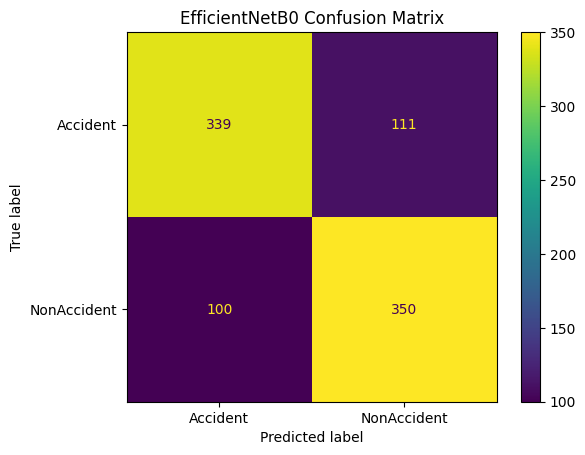

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Accident",
        "NonAccident"
    ]
)

disp.plot(
    values_format="d"
)

plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

In [ ]:
print("=" * 70)
print("EFFICIENTNETB0 THRESHOLD ANALYSIS")
print("=" * 70)

# Calculate accident probabilities from the model's 'NonAccident' predictions
# Using `all_predictions` which is available and contains the same data as y_prob_nonaccident
accident_probability = 1 - all_predictions

for threshold in [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]:

    predictions = np.where(
        accident_probability >= threshold,
        0,
        1
    )

    acc = accuracy_score(
        y_true,
        predictions
    )

    prec = precision_score(
        y_true,
        predictions,
        pos_label=0,
        zero_division=0
    )

    rec = recall_score(
        y_true,
        predictions,
        pos_label=0,
        zero_division=0
    )

    f1_score_value = f1_score(
        y_true,
        predictions,
        pos_label=0,
        zero_division=0
    )

    matrix = confusion_matrix(
        y_true,
        predictions
    )

    missed_accidents = matrix[0][1]
    false_alarms = matrix[1][0]

    print(f"\nThreshold: {threshold * 100:.0f}%")
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {prec * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    print(f"F1 Score : {f1_score_value * 100:.2f}%")
    print(f"Missed Accidents: {missed_accidents}")
    print(f"False Alarms:     {false_alarms}")

EFFICIENTNETB0 THRESHOLD ANALYSIS

Threshold: 30%
Accuracy : 70.56%
Precision: 63.70%
Recall   : 95.56%
F1 Score : 76.44%
Missed Accidents: 20
False Alarms:     245

Threshold: 40%
Accuracy : 76.56%
Precision: 72.01%
Recall   : 86.89%
F1 Score : 78.75%
Missed Accidents: 59
False Alarms:     152

Threshold: 50%
Accuracy : 76.56%
Precision: 77.22%
Recall   : 75.33%
F1 Score : 76.27%
Missed Accidents: 111
False Alarms:     100

Threshold: 60%
Accuracy : 71.89%
Precision: 83.85%
Recall   : 54.22%
F1 Score : 65.86%
Missed Accidents: 206
False Alarms:     47

Threshold: 70%
Accuracy : 65.89%
Precision: 90.86%
Recall   : 35.33%
F1 Score : 50.88%
Missed Accidents: 291
False Alarms:     16

Threshold: 80%
Accuracy : 59.44%
Precision: 94.74%
Recall   : 20.00%
F1 Score : 33.03%
Missed Accidents: 360
False Alarms:     5

Threshold: 90%
Accuracy : 52.78%
Precision: 96.30%
Recall   : 5.78%
F1 Score : 10.90%
Missed Accidents: 424
False Alarms:     1


In [ ]:
model.save(
    "/content/efficientnetb0_accident_detection.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
model.save_weights(
    "/content/model_weights.weights.h5"
)

print("Weights saved.")

Weights saved.


In [ ]:
model_json = model.to_json()

with open(
    "/content/model.json",
    "w"
) as json_file:

    json_file.write(model_json)

print("model.json saved.")

model.json saved.


In [ ]:
from google.colab import files

files.download(
    "/content/model.json"
)

files.download(
    "/content/model_weights.weights.h5"
)

files.download(
    "/content/efficientnetb0_accident_detection.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_prob_nonaccident = model.predict(
    test_data,
    verbose=1
).flatten()

accident_probability = 1 - y_prob_nonaccident

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step


In [ ]:
print("=" * 60)
print("MODEL VERIFICATION")
print("=" * 60)

print("Model name:", model.name)
print("Model type:", type(model).__name__)

print("\nModel input:")
print(model.input_shape)

print("\nModel output:")
print(model.output_shape)

print("\nFirst 20 EfficientNet predictions:")

efficientnet_predictions = model.predict(
    test_data,
    verbose=1
).flatten()

print(
    np.round(
        efficientnet_predictions[:20],
        4
    )
)

print("\nFirst 20 Accident probabilities:")

efficientnet_accident_probs = (
    1 - efficientnet_predictions
)

print(
    np.round(
        efficientnet_accident_probs[:20],
        4
    )
)

MODEL VERIFICATION
Model name: EfficientNetB0_Accident_Detection
Model type: Functional

Model input:
(None, 224, 224, 3)

Model output:
(None, 1)

First 20 EfficientNet predictions:
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
[2.400e-03 8.236e-01 9.318e-01 1.200e-02 1.660e-02 1.446e-01 6.000e-04
 3.460e-02 1.400e-03 8.000e-02 3.619e-01 4.580e-02 2.532e-01 3.890e-02
 1.000e-04 5.603e-01 9.000e-04 6.300e-03 1.624e-01 5.700e-03]

First 20 Accident probabilities:
[0.9976 0.1764 0.0682 0.988  0.9834 0.8554 0.9994 0.9654 0.9986 0.92
 0.6381 0.9542 0.7468 0.9611 0.9999 0.4397 0.9991 0.9937 0.8376 0.9943]


IMAGE: 4589.jpg
Actual Class    : NonAccident
Predicted Class : NonAccident
Confidence      : 78.19%
Accident Prob.  : 21.81%
NonAccident Prob: 78.19%
Status          : ✓ CORRECT


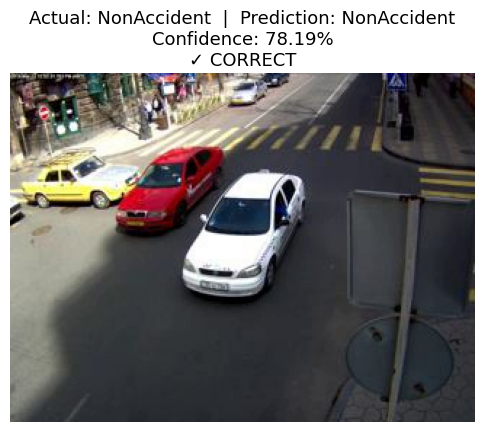

IMAGE: 639.jpg
Actual Class    : Accident
Predicted Class : Accident
Confidence      : 71.30%
Accident Prob.  : 71.30%
NonAccident Prob: 28.70%
Status          : ✓ CORRECT


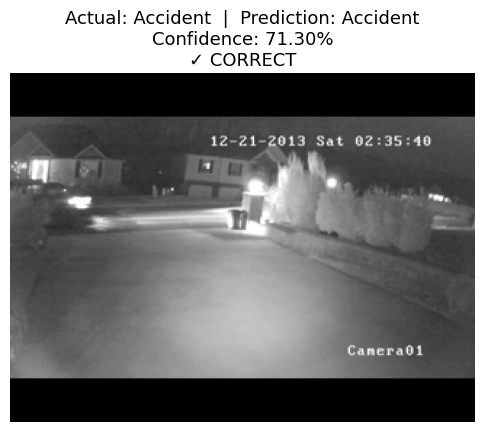

IMAGE: 3199.jpg
Actual Class    : Accident
Predicted Class : Accident
Confidence      : 91.31%
Accident Prob.  : 91.31%
NonAccident Prob: 8.69%
Status          : ✓ CORRECT


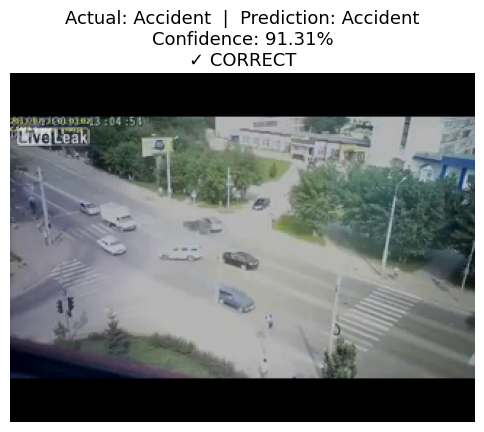

IMAGE: 7586.jpg
Actual Class    : NonAccident
Predicted Class : NonAccident
Confidence      : 99.92%
Accident Prob.  : 0.08%
NonAccident Prob: 99.92%
Status          : ✓ CORRECT


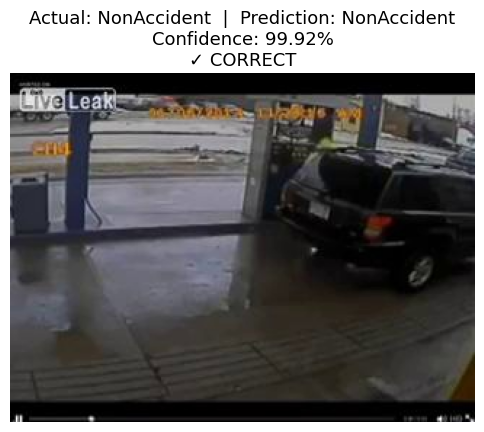

IMAGE: 1539.jpg
Actual Class    : Accident
Predicted Class : NonAccident
Confidence      : 90.52%
Accident Prob.  : 9.48%
NonAccident Prob: 90.52%
Status          : ✗ WRONG


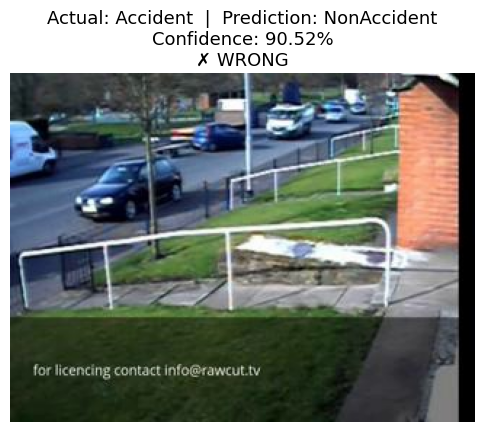

IMAGE: 5370.jpg
Actual Class    : Accident
Predicted Class : Accident
Confidence      : 88.94%
Accident Prob.  : 88.94%
NonAccident Prob: 11.06%
Status          : ✓ CORRECT


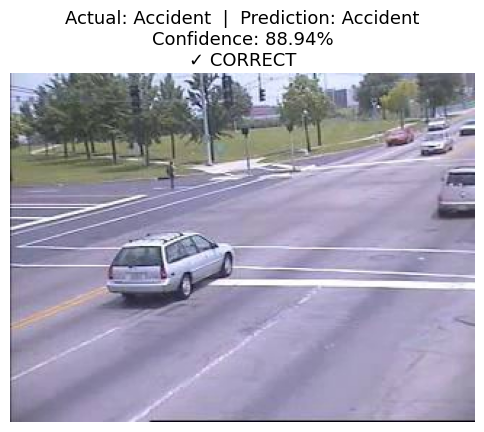

IMAGE: 2615.jpg
Actual Class    : Accident
Predicted Class : Accident
Confidence      : 99.90%
Accident Prob.  : 99.90%
NonAccident Prob: 0.10%
Status          : ✓ CORRECT


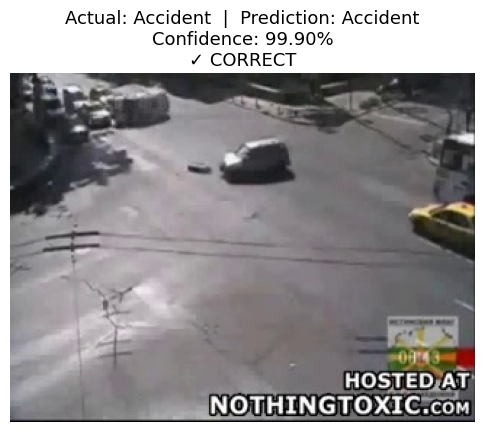

IMAGE: 5417.jpg
Actual Class    : Accident
Predicted Class : Accident
Confidence      : 77.31%
Accident Prob.  : 77.31%
NonAccident Prob: 22.69%
Status          : ✓ CORRECT


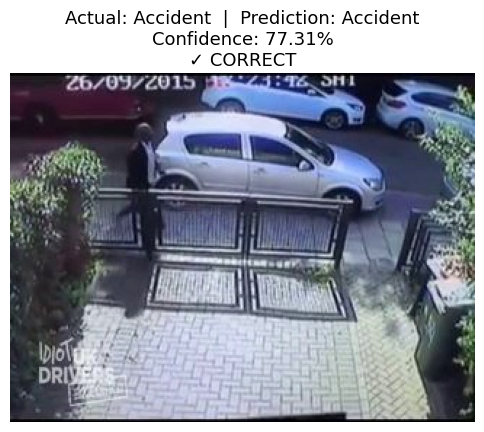

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# SETTINGS
# ============================================================

TEST_PATH = "/content/cnn_dataset/test"

# Number of images to test
NUM_IMAGES = 8

# ============================================================
# GET TEST IMAGES
# ============================================================

image_paths = []

for class_name in ["Accident", "NonAccident"]:
    class_path = os.path.join(TEST_PATH, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        ):
            image_paths.append(
                (
                    os.path.join(class_path, file_name),
                    class_name
                )
            )

# Randomly select images
random.seed(42)

selected_images = random.sample(
    image_paths,
    min(NUM_IMAGES, len(image_paths))
)

# ============================================================
# TEST IMAGES
# ============================================================

for image_path, actual_class in selected_images:

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize for EfficientNetB0
    img = image.resize((224, 224))

    # Convert to NumPy
    img_array = np.array(img).astype(
        np.float32
    )

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # ========================================================
    # PREDICTION
    # ========================================================

    raw_prediction = float(
        model.predict(
            img_array,
            verbose=0
        )[0][0]
    )

    # Model output = NonAccident probability
    accident_probability = 1 - raw_prediction
    nonaccident_probability = raw_prediction

    # ========================================================
    # CLASS DECISION
    # ========================================================

    if accident_probability >= 0.5:

        predicted_class = "Accident"
        confidence = accident_probability

    else:

        predicted_class = "NonAccident"
        confidence = nonaccident_probability

    # ========================================================
    # RESULT
    # ========================================================

    result = (
        "✓ CORRECT"
        if actual_class == predicted_class
        else
        "✗ WRONG"
    )

    print("=" * 60)
    print("IMAGE:", os.path.basename(image_path))
    print("Actual Class    :", actual_class)
    print("Predicted Class :", predicted_class)
    print("Confidence      :", f"{confidence * 100:.2f}%")
    print("Accident Prob.  :", f"{accident_probability * 100:.2f}%")
    print("NonAccident Prob:", f"{nonaccident_probability * 100:.2f}%")
    print("Status          :", result)
    print("=" * 60)

    # ========================================================
    # DISPLAY IMAGE
    # ========================================================

    plt.figure(figsize=(6, 5))

    plt.imshow(image)

    plt.title(
        f"Actual: {actual_class}  |  "
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%\n"
        f"{result}",
        fontsize=13
    )

    plt.axis("off")
    plt.show()

EFFICIENTNETB0 - ACTUAL VS PREDICTION
4589.jpg        | Actual: NonAccident  | Pred: NonAccident  |  78.19% | ✓


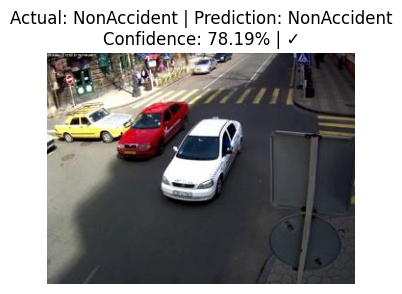

639.jpg         | Actual: Accident     | Pred: Accident     |  71.30% | ✓


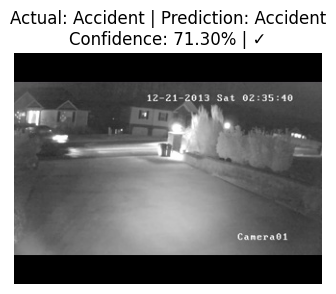

3199.jpg        | Actual: Accident     | Pred: Accident     |  91.31% | ✓


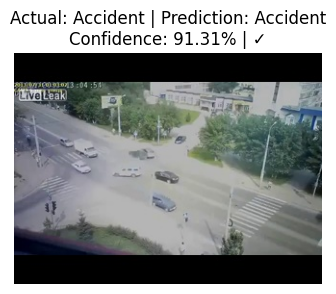

7586.jpg        | Actual: NonAccident  | Pred: NonAccident  |  99.92% | ✓


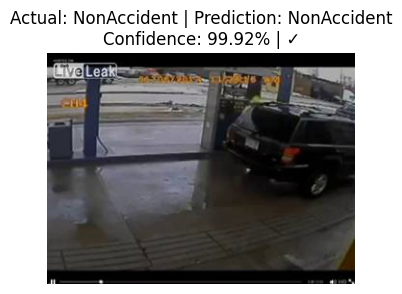

1539.jpg        | Actual: Accident     | Pred: NonAccident  |  90.52% | ✗


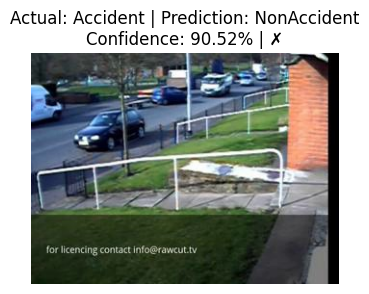

5370.jpg        | Actual: Accident     | Pred: Accident     |  88.94% | ✓


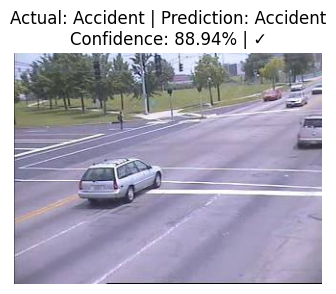

2615.jpg        | Actual: Accident     | Pred: Accident     |  99.90% | ✓


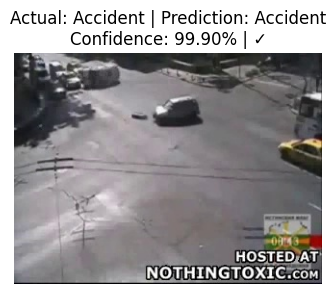

5417.jpg        | Actual: Accident     | Pred: Accident     |  77.31% | ✓


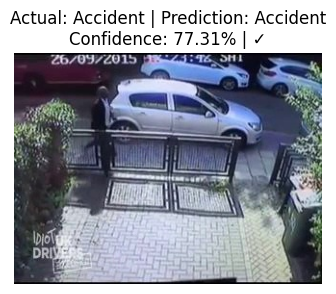

12355.jpg       | Actual: NonAccident  | Pred: NonAccident  |  99.51% | ✓


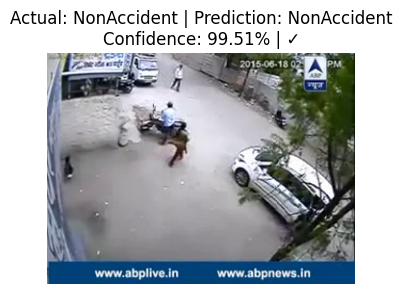

2444.jpg        | Actual: Accident     | Pred: Accident     |  99.49% | ✓


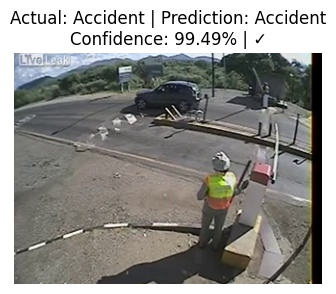

8207.jpg        | Actual: NonAccident  | Pred: NonAccident  |  99.51% | ✓


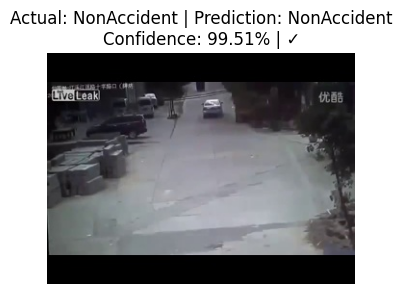

13341.jpg       | Actual: NonAccident  | Pred: NonAccident  |  99.55% | ✓


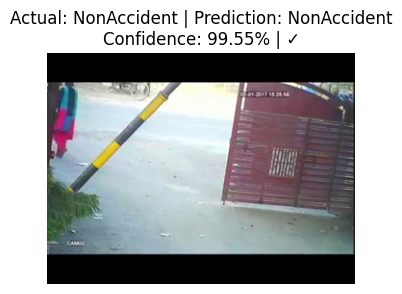

3269.jpg        | Actual: NonAccident  | Pred: NonAccident  |  99.56% | ✓


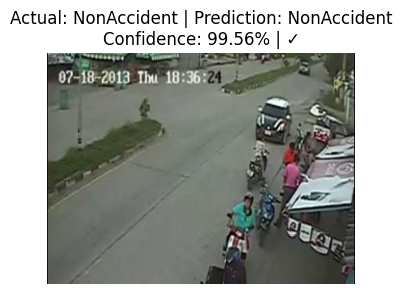

2202.jpg        | Actual: Accident     | Pred: NonAccident  |  58.11% | ✗


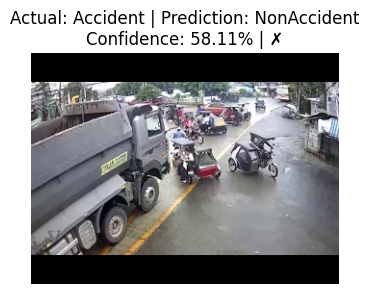

8781.jpg        | Actual: NonAccident  | Pred: NonAccident  |  91.73% | ✓


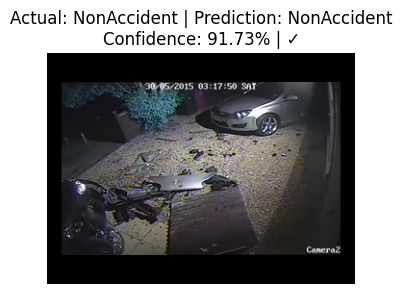

5169.jpg        | Actual: Accident     | Pred: Accident     |  90.24% | ✓


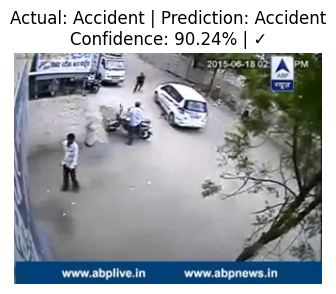

3884.jpg        | Actual: Accident     | Pred: Accident     |  60.04% | ✓


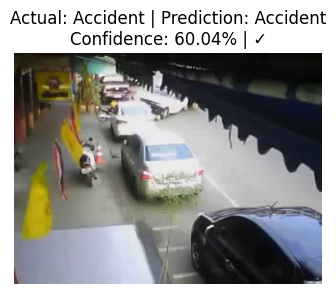

1751.jpg        | Actual: Accident     | Pred: Accident     |  99.98% | ✓


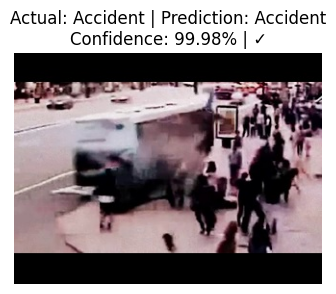

5786.jpg        | Actual: Accident     | Pred: Accident     |  97.84% | ✓


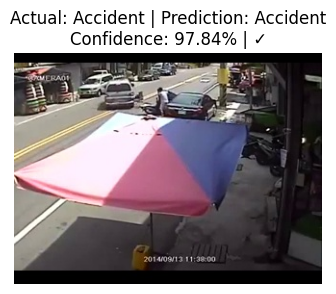

1364.jpg        | Actual: Accident     | Pred: Accident     |  97.76% | ✓


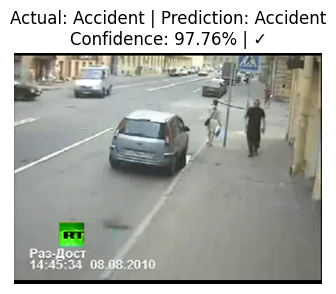

Correct: 18/20
Accuracy: 90.00%


In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

TEST_PATH = "/content/cnn_dataset/test"

images = []
for cls in ["Accident", "NonAccident"]:
    folder = os.path.join(TEST_PATH, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            images.append((os.path.join(folder, f), cls))

random.seed(42)
selected = random.sample(images, 20)

correct = 0

print("=" * 65)
print("EFFICIENTNETB0 - ACTUAL VS PREDICTION")
print("=" * 65)

for path, actual in selected:
    img = Image.open(path).convert("RGB")
    x = np.array(img.resize((224, 224)), dtype=np.float32)
    x = np.expand_dims(x, 0)

    raw = float(model.predict(x, verbose=0)[0][0])

    # 0 = Accident, 1 = NonAccident
    accident_prob = 1 - raw

    if accident_prob >= 0.5:
        pred = "Accident"
        conf = accident_prob
    else:
        pred = "NonAccident"
        conf = raw

    status = "✓" if actual == pred else "✗"
    correct += actual == pred

    print(
        f"{os.path.basename(path):15} | "
        f"Actual: {actual:12} | "
        f"Pred: {pred:12} | "
        f"{conf*100:6.2f}% | {status}"
    )

    plt.figure(figsize=(4, 3))
    plt.imshow(img)
    plt.title(
        f"Actual: {actual} | Prediction: {pred}\n"
        f"Confidence: {conf*100:.2f}% | {status}"
    )
    plt.axis("off")
    plt.show()

print("=" * 65)
print(f"Correct: {correct}/20")
print(f"Accuracy: {correct/20*100:.2f}%")
print("=" * 65)

# **Thanks**